<a href="https://colab.research.google.com/gist/MBarriosCastellanos/21dd7c8060842195e5f8937ac1a09f35/power_crew.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Objetivos principales del diseño de un tornillo de potencia:**

1. **Selección de materiales y geometría:**
   - Seleccionar el mejor material y concebir la mejor geometría para cumplir con las especificaciones de diseño.
   - El tornillo debe diseñarse para trabajar en tensión siempre que sea posible.
   - Si el tornillo debe soportar compresión debido a la carga axial, se debe considerar el **pandeo** al determinar su diámetro.

2. **Análisis de esfuerzos en la zona de contacto de las roscas:**
   - Es importante determinar los esfuerzos de flexión, apoyo y cortante en la zona de contacto de las roscas para prevenir fallas por desgaste o fatiga.
   - La concentración de esfuerzos en las raíces de las roscas más cargadas puede ser un factor crítico, especialmente bajo cargas cíclicas.
   - Los estándares de roscas para tornillos de potencia suelen limitar la longitud de contacto a **dos veces el diámetro mayor** del tornillo. Sin embargo, debido a tolerancias de fabricación y cambios en el paso inducidos por la carga, las primeras **una, dos o tres roscas** soportan la mayor parte de la carga.

3. **Teorías de esfuerzos combinados:**
   - En ciertos puntos críticos, los esfuerzos nominales del tornillo pueden combinarse con esfuerzos locales en las roscas, por lo que puede ser necesario aplicar una **teoría de esfuerzos combinados**.


# **Procedimiento sugerido para el diseño:**


## **Paso 1: Selección preliminar de materiales y geometría:**
   - Seleccionar tentativamente los materiales para el tornillo y la tuerca, incluyendo el tratamiento térmico.
   - Seleccionar la forma de la rosca, consultando estándares de roscas.
   - Seleccionar tentativamente el tipo de cojinete de empuje (thrust collar bearing).



## **Paso 2: Estimación del diámetro del tornillo:**
   - Si el tornillo está en compresión o si hay cargas excéntricas o momentos de flexión externos, estimar un diámetro tentativo basado en el **pandeo**.
   - Si el pandeo no es un modo de falla potencial, estimar el diámetro tentativo basado en el **esfuerzo directo**.
   - Usar el diámetro resultante como el **diámetro de la raíz** para obtener un resultado ligeramente conservador.



## **Paso 3: Determinación de las dimensiones de la rosca:**
   - Usando el diámetro de la raíz tentativo del Paso 2 y la forma de la rosca seleccionada, determinar el **paso**, el **avance** y otras dimensiones de la rosca.


## **Paso 4: Cálculo del torque de accionamiento:**
   - Utilizando las las especificaciones de diseño, calcular el **torque de accionamiento** requerido para el conjunto del tornillo de potencia.



## **Paso 5: Identificación de puntos críticos y cálculo de esfuerzos:**
   - Identificar las secciones y puntos críticos aplicables.
   - Calcular los esfuerzos directos nominales y los esfuerzos cortantes torsionales en el tornillo.
   - Calcular los esfuerzos de flexión, cortante (desgarre) y presión de apoyo en la zona de contacto de las roscas.
   - Donde sea pertinente, calcular los **esfuerzos principales** para aplicar teorías de esfuerzos combinados o teorías de falla.



## **Paso 6: Cálculo de los esfuerzos de diseño:**
   - Usando un **factor de seguridad** apropiado, calcular el esfuerzo de diseño para cada material candidato (ver sección 2.12).



## **Paso 7: Ajuste de dimensiones y verificación final:**
   - Usando los esfuerzos principales determinados en el Paso 5, los esfuerzos de diseño del Paso 6 y las teorías de esfuerzos combinados, ajustar las dimensiones según sea necesario para lograr un diseño aceptable.
   - La aceptabilidad de la **presión de apoyo** entre las roscas del tornillo y la tuerca puede basarse en los criterios de cojinetes planos.





## **Observaciones**
- Las primeras roscas en la zona de contacto soportan la mayor parte de la carga debido a tolerancias de fabricación y cambios en el paso.
- La concentración de esfuerzos en las raíces de las roscas es un factor crítico bajo cargas cíclicas.
- Es esencial considerar tanto los esfuerzos nominales como los locales para garantizar un diseño seguro y eficiente.



# Diseño Preliminar y Análisis de Esfuerzos para un Tornillo de Potencia

Consideremos el uso de un conjunto de tornillo de potencia como mecanismo de accionamiento para una compactadora mecánica utilizada en una planta de fabricación de láminas metálicas. El dispositivo se usará para compactar chatarra de lámina metálica en pequeños "bloques" cilíndricos para su envío a una instalación de reciclaje. La configuración propuesta se muestra en la Figura.


In [ ]:
import numpy as np

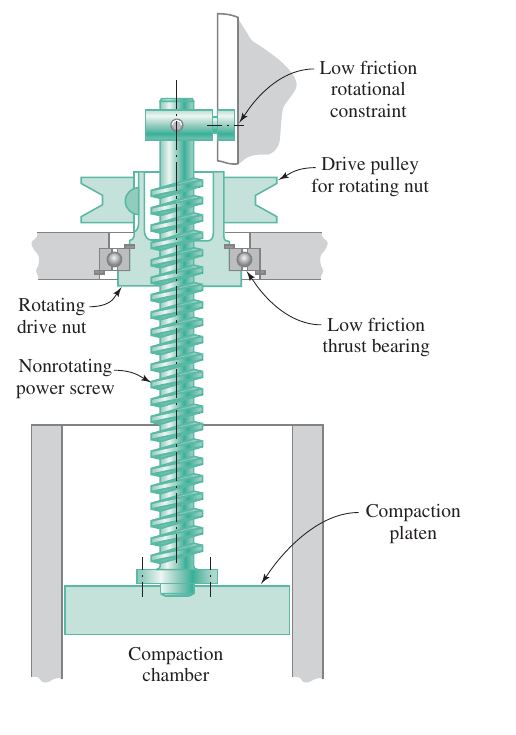

La longitud estimada sin soporte del tornillo cuando está completamente extendido (corresponde a la carga axial máxima) es de **72 pulgadas**, y los soportes de los extremos de la tuerca y la platina pueden considerarse fijados **con pasadores** en cada ubicación. La tuerca giratoria es accionada por una correa en V acoplada a la polea mostrada. La tuerca giratoria, soportada sobre un rodamiento de empuje de elemento rodante de baja fricción, provoca que el tornillo (y la platina acoplada) se desplace hacia arriba y hacia abajo.

El tornillo está restringido contra la rotación mediante un seguidor de elemento rodante de **baja fricción que se desliza en una ranura vertical en el marco de soporte.

Cuando la chatarra metálica en la cámara de compactación se comprime lo suficiente como para generar una fuerza de reacción sobre el plato de compactación de **10,000 lb**, un sensor de fuerza activa un interruptor de inversión en el accionamiento, retrayendo el tornillo a su posición totalmente elevada.

- Se debe realizar una determinación preliminar de una forma de rosca y un tamaño de tornillo adecuados para este dispositivo.

- La gerencia de ingeniería ha especificado un factor de seguridad de diseño de 1.5 y se anticipa que las roscas estarán lubricadas.


## Paso 1: Selección de materiales y tipo de rosca


In [ ]:
P_max = 10000   # lb
F_s = 1.5       # Factor de seguridad
L_e = 72        # in

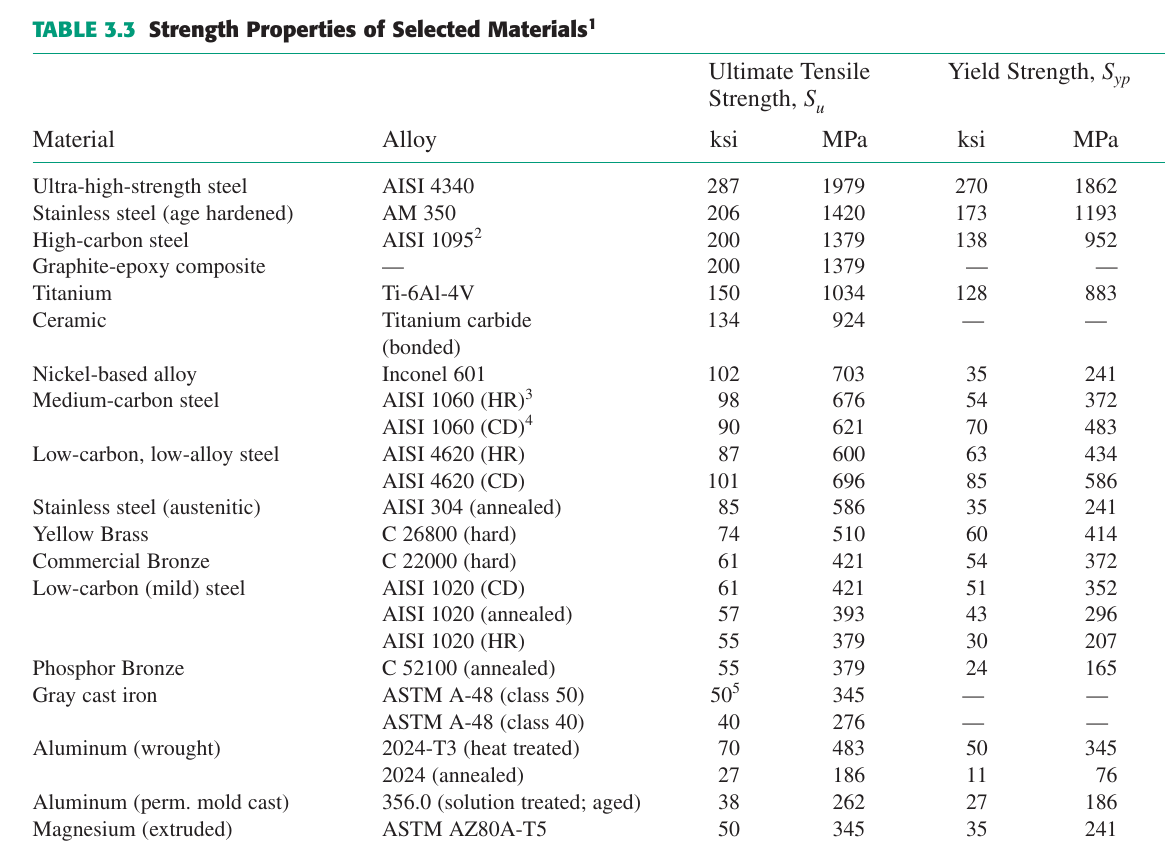

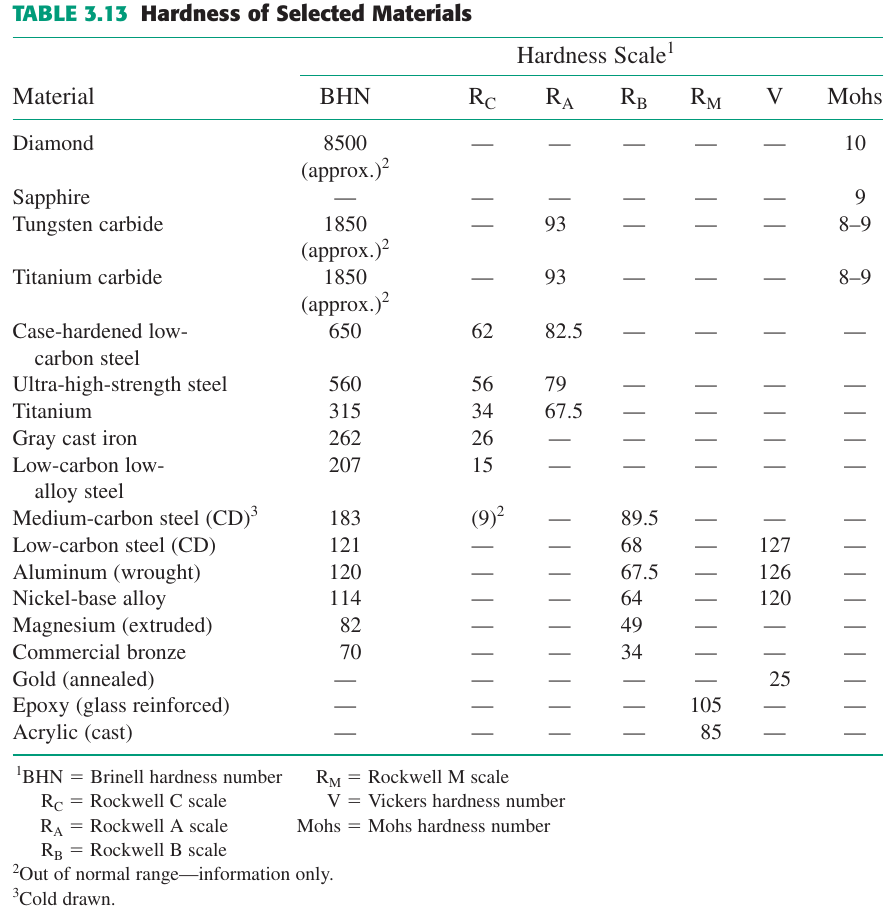

Seleccionamos un tornillo de acero y una tuerca de bronce. Para fines de diseño preliminar, utilizaremos:
- **Tornillo:** Acero 1020
- **Tuerca:** Bronce C-2200
- **Rosca:** ACME

In [ ]:
Su = 61000  # Acero 1020 limite de rotura
Sy = 51000  # Acero 1020 limite de fluencia

## Paso 2: Cálculo del diámetro de raíz estimado

### Teoria de Columnas

---
1. **Relación de esbeltez:**

$
\text{Relación de esbeltez} = \frac{L_e}{r}
$

Donde:

- $L_e $: Longitud efectiva de la columna.
- $r $: Radio de giro ($r = \sqrt{I/A} $).

Si la relación de esbeltez es menor que **10** se considera que es una columna corta  y no falla por pandeo (Norton 2021 Aprox)


2. **Relación de esbeltez crítica ($C_c $):**

$
C_c = \sqrt{\frac{2\pi^2 E}{S_y}}
$

Donde:

- $E$: Módulo de elasticidad del material.
- $Sy$: Límite de fluencia del material.


3. **Carga crítica de pandeo (Fórmula de Euler):**

$
P_{cr} = \frac{\pi^2 E I}{(L_e)^2}
$

Donde:

- $I $: Momento de inercia de la sección transversal.

4. **Carga crítica para columnas intermedias (Fórmula de Johnson):**

$
P_{cr} = A \left( S_y - \frac{S_y^2}{4 \pi^2 E} \left( \frac{L_e}{r} \right)^2 \right)
$

Donde:
- $A $: Área de la sección transversal.



5. **Carga crítica para columnas cortas (Falla por compresión):**

$
P_{cr} = S_y \cdot A
$


6. **Longitud efectiva ($L_e $):**

$
L_e = K \cdot L
$

Donde:
- $K $: Factor de longitud efectiva (depende de las condiciones de apoyo).
- $L $: Longitud real de la columna.

---

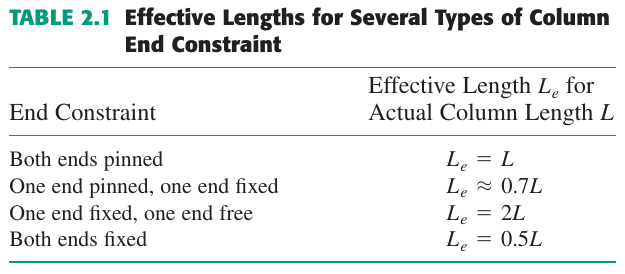

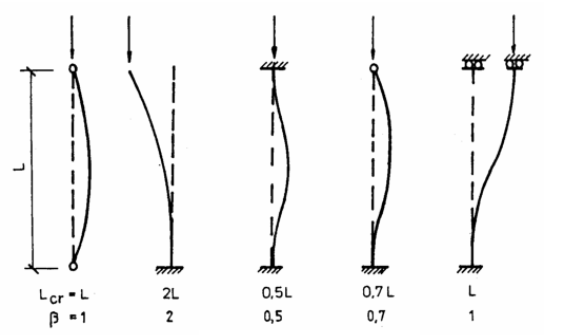

### Calculos

In [ ]:
# Carga crítica requerida
P_cr_req = F_s * P_max
print(f'carga critica {P_cr_req} Lb')

# Momento de inercia requerido
E = 30e6  # psi (Módulo de elasticidad del acero 1020)
I_req = (P_cr_req * L_e**2) / (np.pi**2 * E)
print(f'Inercia requerida {I_req} In')

# Cálculo del diámetro de raíz estimado
dr_est = (((I_req * 64)/np.pi)**(1/4))
print(f'dr est {dr_est} in')

carga critica 15000.0 Lb
Inercia requerida 0.2626245080009395 In
dr est 1.520867356025262 in


## Paso 3: Selección del tamaño de rosca estándar

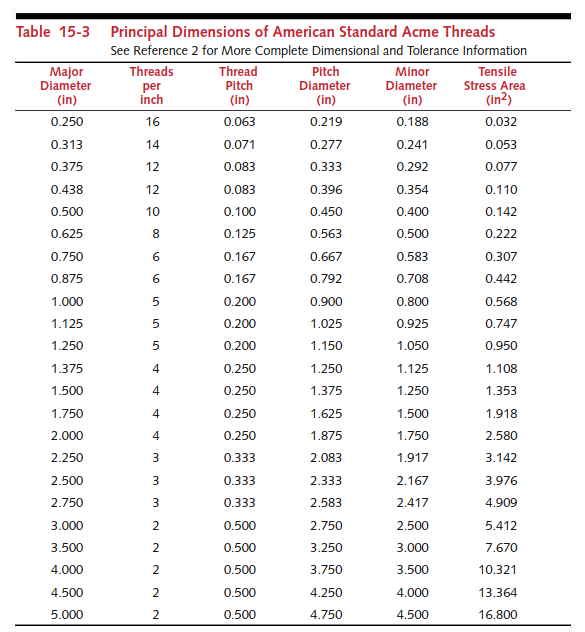

El tamaño de rosca más cercano es **2 pulgadas de diámetro mayor**, con:
- **Paso**: 0.25 in
- **Diámetro de raíz**: 1.75 in

In [ ]:
# seleccionamos un tornillo de diametro 2
d = 2        # in
d_r = 1.75   # in
d_p = 1.875  # in
p = 1/4      # in

## Paso 4: Cálculo del torque requerido para accionamiento

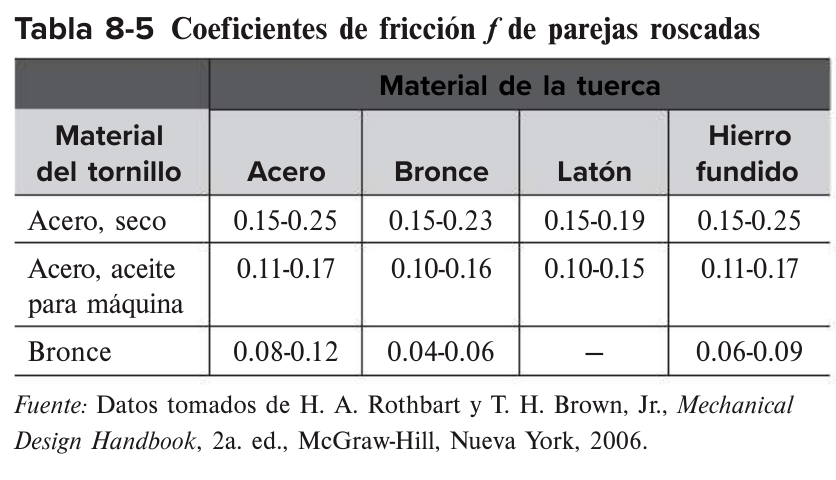

#### **Datos del problema:**

- **Coeficiente de fricción (lubricado):** $ \mu = 0.11-0.17$.

- **Diámetro medio del tornillo ($ d_p $):** 1.875 in .
- **Ángulo de la rosca Acme ($ \alpha $):** 14.5°.
- **Paso de la rosca ($ p $):** 0.25 in.



#### **Ecuación del torque de accionamiento (12-11):**
La ecuación para calcular el torque de accionamiento ($ T_R $) es:

$
 T_u = \frac{P d_p}{2} \frac{
            (\mu \pi d_p + L cos \alpha)}{(
                \pi d_p \cos \alpha - \mu L)} + \mu_c \frac{P d_c}{2}
$

Donde:
- $ P $: Carga axial.
- $ \mu $: Coeficiente de fricción.
- $ d_p $: Diámetro primitivo del tornillo.
- $ \alpha $: Ángulo de la rosca.
- $ p $: Paso de la rosca.


In [ ]:
# Datos del problema
P = P_max  # Carga axial en lb
mu = 0.11  # Coeficiente de fricción (lubricado)
#d_p = 1.88  # Diámetro medio en in
alpha = 14.5*np.pi/180  # Ángulo de la rosca

d_c = 3
mu_c = 0
L = p

T_su = (P * d_p / 2) * (
    (mu * np.pi * d_p + L*np.cos(alpha)) / (
        np.pi * d_p*np.cos(alpha) - mu * L))

# Término 2: Torque debido al collar
T_c = mu_c * P * (d_c / 2)

# Torque total
T_u = T_su #+ T_c
print(f"Torque {T_u} lb-in")

Torque 1470.1551007316577 lb-in


## Paso 5: Verificación de esfuerzos en los puntos críticos

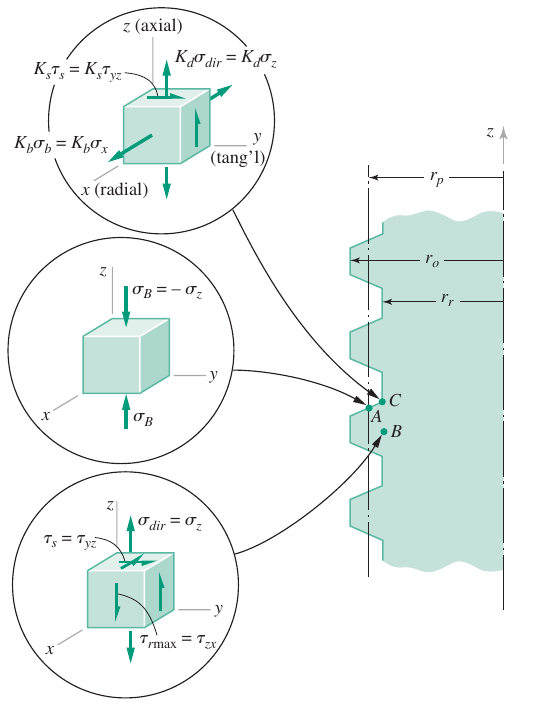

### Punto Critico A

Para el punto crítico A, en la zona de contacto entre las roscas del tornillo y las roscas de la tuerca, se asumirá que **3 roscas soportan la carga completa**.

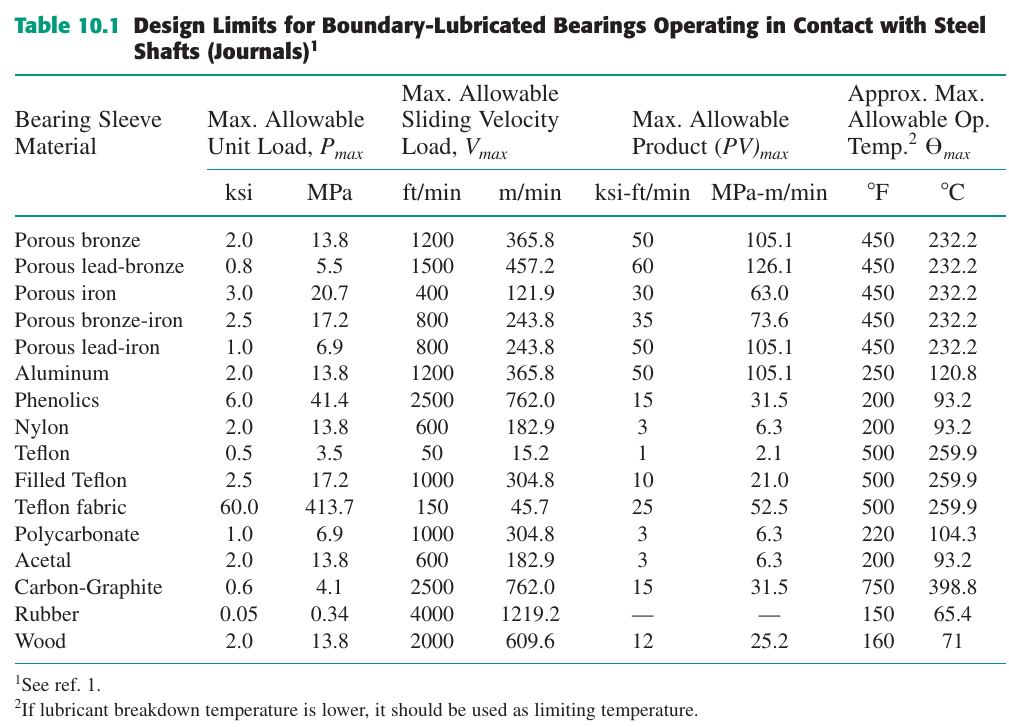

#### Calculo con tornillo de 2''

In [ ]:
# Seleccionamos un tornillo de diametro 3 pulgadas
n = 2 # Número de roscas que soportan la carga

# Cálculo del área proyectada (A_p)
A_p =  n * (np.pi * (d**2 - d_r**2)) / 4

# Cálculo del esfuerzo de flexión (sigma_b)
sigma_b = P_max / A_p

# Resultados
print(f"El área proyectada (A_p) es: {A_p:.4f} in²")
print(f"El esfuerzo de flexión (sigma_b) es: {sigma_b:.2f} psi")

El área proyectada (A_p) es: 1.4726 in²
El esfuerzo de flexión (sigma_b) es: 6790.61 psi


#### Calculo con tornillo de 3''

In [ ]:
# Seleccionamos un tornillo de diametro 3 pulgadas
n = 2.5  # Número de roscas que soportan la carga
d = 3  # Diámetro exterior del tornillo en pulgadas
d_r = 2.5  # Diámetro interior del tornillo en pulgadas
d_p = 2.75 # diametro primitivo
p = 1/2
L = p

# Cálculo del área proyectada (A_p)
A_p =  n * (np.pi * (d**2 - d_r**2)) / 4

# Cálculo del esfuerzo de flexión (sigma_b)
sigma_b = P_max / A_p

# Resultados
print(f"El área proyectada (A_p) es: {A_p:.4f} in²")
print(f"El esfuerzo de flexión (sigma_b) es: {sigma_b:.2f} psi")

El área proyectada (A_p) es: 5.3996 in²
El esfuerzo de flexión (sigma_b) es: 1851.98 psi


Esta configuración hace que el punto crítico A sea aceptable.  
El cálculo del torque debe modificarse para el nuevo tamaño del tornillo a:

In [ ]:
# Datos del problema
P = P_max  # Carga axial en lb
L = p      # Avance tornillo de un solo hilo
T_su = (P * d_p / 2) * (
    (mu * np.pi * d_p + L*np.cos(alpha)) / (
        np.pi * d_p*np.cos(alpha) - mu * L))

# Término 2: Torque debido al collar
T_c = mu_c * P * (d_c / 2)

# Torque total
T_u = T_su #+ T_c
print(f"Torque {T_u} lb-in")

Torque 2373.644688697647 lb-in


### Punto Critico B



Para el punto crítico B en el eje neutro de flexión de la rosca, los componentes de esfuerzo nominal son:  
- Esfuerzo cortante torsional en el tornillo ($ \tau_s$),

  $
  \tau_{s} = \frac{16 T}{\pi d_r^3}
  $

- Esfuerzo directo en el tornillo ($ \sigma_{\text{dir}}$),  
  $
  \sigma_{z} = \frac{4P}{\pi d_r^2}
  $

- Esfuerzo cortante transversal máximo debido a la flexión de la rosca ($ \tau_{r\text{-max}}$).

  $
  \tau_{zx} = \frac{3}{2}\frac{P}{ \pi\, d_r\, w_i\, p  \,n }
  $


In [ ]:
# Parámetros de entrada
T = T_u  # Torque en in-lb
P = P_max # Carga axial en lb
w_i = 0.77  # factor de area

# Cálculo del esfuerzo cortante torsional (tau_s)
tau_s = (16 * T) / (np.pi * d_r**3)

# Cálculo del esfuerzo directo (sigma_z)
sigma_z = (4 * P) / (np.pi * d_r**2)

# Cálculo del esfuerzo cortante transversal (tau_zx)
tau_zx = (3 / 2) * (P / (np.pi * d_r * w_i * p * n))

# Resultados
print(f"El esfuerzo cortante torsional (tau_s) es: {tau_s:.2f} psi")
print(f"El esfuerzo directo (sigma_z) es: {sigma_z:.2f} psi")
print(f"El esfuerzo cortante transversal (tau_zx) es: {tau_zx:.2f} psi")

El esfuerzo cortante torsional (tau_s) es: 773.69 psi
El esfuerzo directo (sigma_z) es: 2037.18 psi
El esfuerzo cortante transversal (tau_zx) es: 1984.27 psi


### Punto Critico C

Para el punto critico C en la raiz del diente se calcula

- El esfuerzo normal adiciona debido al pandeo de la viga:

  $\sigma_{x} = \frac{3 P (d_p - d_r)}{(\pi d_r n)(p w_i)^2} $

- Esfuerzo cortante torsional en el tornillo ($ \tau_s$),

  $
  \tau_{s} = \frac{16 T}{\pi d_r^3}
  $

- Esfuerzo directo en el tornillo ($ \sigma_{\text{dir}}$),  
  $
  \sigma_{z} = \frac{4P}{\pi d_r^2}
  $


In [ ]:
# Parámetros de entrada
P = P_max  # Carga axial en lb

# Cálculo del esfuerzo (sigma_x)
numerator = 3 * P * (d_p - d_r)
denominator = (np.pi * d_r * n) * (p * w_i)**2
sigma_x = numerator / denominator

# Resultado
print(f"El esfuerzo (sigma_x) es: {sigma_x:.2f} psi")

El esfuerzo (sigma_x) es: 2576.97 psi


## Paso 6: Verificación del Factor de seguridad

- En el punto crítico A, donde el modo de falla determinante probable es el desgaste, el factor de seguridad ya está incluido en los datos de presión admisible de la Tabla. Por lo tanto, la tensión de diseño (presión admisible de diseño) de 2000 psi no requiere ninguna modificación adicional.

- En los puntos críticos B y C, donde el modo de falla determinante probable es la fatiga, la tensión de diseño se puede determinar de la siguiente manera:
 Estos son Su = 61 ksi, Syp = 51 ksi y e (2 pulgadas) = ​​15%. Si se toma el límite de resistencia a la fatiga del material como 0,5 S u,

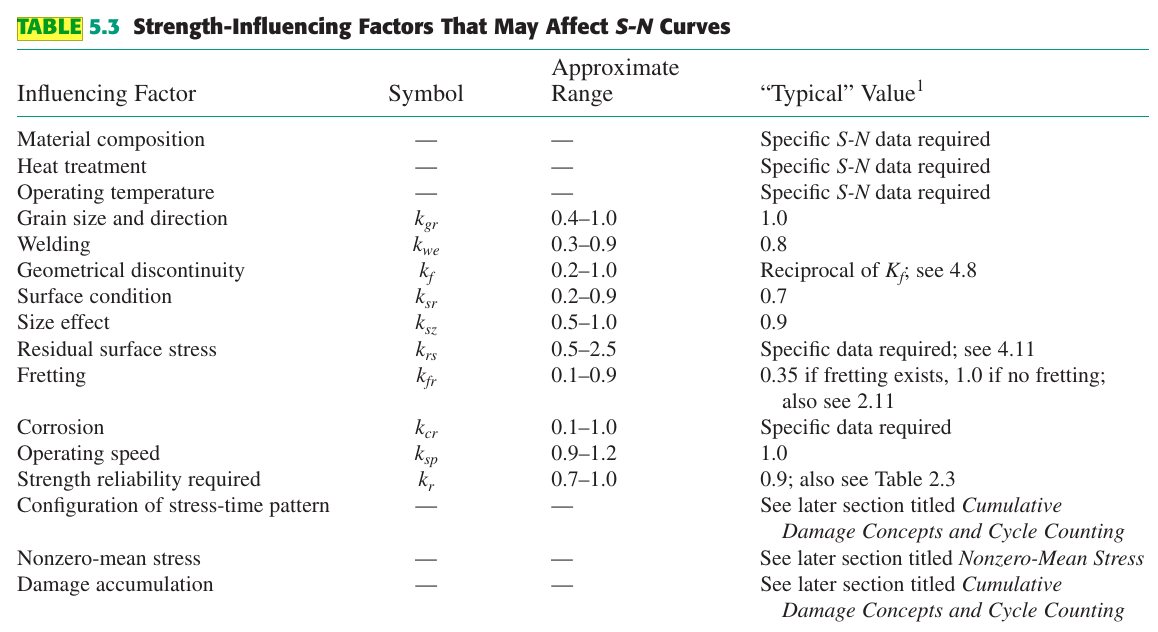

In [ ]:
Su = 61000      # psi Esfuerzo ultimo de fluencia
Sf = 0.5 * Su   # psi E

# Factores de modificación
k_gr = 1.0  # tamaño de grano
k_we = 1.0  # No welding anticipated
k_f = 1.0   # Uniform shape specified
k_sr = 0.65 # Torneada
k_sz = 0.9  # efecto de tamaño
k_rs = 1.0  #
k_fr = 1.0  #
k_cr = 0.9  # Corrosion leve
k_sp = 1.0  # From
k_r = 0.9   # From Table 5.4 for R = 90

# Cálculo de k_q
k_q = k_gr * k_we * k_f * k_sr * k_sz * k_rs * k_fr * k_cr * k_sp * k_r

# Resultado
print(f"El valor de k_q es: {k_q:.4f}")

S_inf = k_q * Sf
print(f"Falla por fatiga S_inf: {S_inf/1000:.2f} ksi")

El valor de k_q es: 0.4739
Falla por fatiga S_inf: 14.45 ksi


In [ ]:
sigma_diseno = S_inf/F_s # esfuerzo dee diseño
print(f'esfuerzo de diseño Sigma_diseno = {sigma_diseno:.4f} psi')

esfuerzo de diseño Sigma_diseno = 9634.9500 psi


## Paso 7: Carga combinada

### Esfuerzos Multiaxiales de Esfuerzo Cíclico y Teorías de Falla por Fatiga Multiaxial


La mayoría de las situaciones de diseño reales implican cargas fluctuantes que generan **estados multiaxiales de esfuerzo cíclico**. Aunque aún no hay consenso sobre el mejor enfoque para predecir la falla en estos casos, una técnica común para materiales dúctiles es adaptar cíclicamente la expresión del **esfuerzo equivalente**:


$
\sigma_{eq} = \frac{1}{\sqrt{2}} \sqrt{ (\sigma_{x-a} - \sigma_{y-a})^2 + (\sigma_{y-a} - \sigma_{z-a})^2 + (\sigma_{z-a} - \sigma_{x-a})^2 }
$


Para materiales frágiles, se utilizan las ecuaciones de esfuerzo normal principal.

---

**Esfuerzo Equivalente Alternante para Materiales Dúctiles**

Basado en la ecuación de esfuerzo equivalente, el esfuerzo alternante uniaxial equivalente $ \sigma_{a} $ se define como:

$
\sigma_{a} = \sqrt{\frac{1}{2}  \left[(\sigma_{x-a} - \sigma_{y-a})^2 + (\sigma_{y-a} - \sigma_{z-a})^2 + (\sigma_{z-a} - \sigma_{x-a})^2 \right]  + 3( \tau_{xy-a}^2 + \tau_{yz-a}^2 + \tau_{xz-a}^2 )}
$

**Esfuerzo Equivalente Medio para Materiales Dúctiles**

El esfuerzo medio uniaxial equivalente $ \sigma_{eq-m} $ es:

$
\sigma_{m} = \sqrt{\frac{1}{2}  \left[ (\sigma_{x-m} - \sigma_{y-m})^2 + (\sigma_{y-m} - \sigma_{z-m})^2 + (\sigma_{z-m} - \sigma_{x-m})^2 \right]+ 3( \tau_{xy-m}^2 + \tau_{yz-m}^2 + \tau_{xz-m}^2 )}
$

**Caso de Esfuerzo Plano (Simplificación)**

Para **esfuerzo plano** ($ \sigma_z = \tau_{yz} = \tau_{xz} = 0 $):

$
\sigma_{a} = \sqrt{ \sigma_{x-a}^2 + \sigma_{y-a}^2 - \sigma_{x-a}\sigma_{y-a} + 3\tau_{xy-a}^2 }
$

$
\sigma_{m} = \sqrt{ \sigma_{x-m}^2 + \sigma_{y-m}^2 - \sigma_{x-m}\sigma_{y-m} + 3\tau_{xy-m}^2 }
$

---

**Aplicación a Criterios de Falla**

Estas ecuaciones pueden sustituirse en expresiones uniaxiales (como la de Goodman modificada) para considerar estados multiaxiales. Por ejemplo, usando:

- Si $ \sigma_{m} \geq 0 $ y $ \sigma_{\text{max}} \leq S_{yp} $:

    $
    \sigma_{CR} = \frac{\sigma_{a}}{1 - (\sigma_{m}/S_u)}
    $

- Si $ \sigma_{m} \geq 0 $ y $ \sigma_{\text{max}} \geq S_{yp} $:

    $
    \sigma_{CR} = S_{yp}
    $

Donde:

  $
  \sigma_{\text{max}} = \sigma_{a} + \sigma_{m}
  $

---

**Materiales Frágiles bajo Esfuerzo Multiaxial**

Para materiales frágiles, si $ \sigma_1 \geq \sigma_2 \geq \sigma_3 $, se sustituyen $ \sigma_{1a} $ y $ \sigma_{1m} $ en métodos uniaxiales. Por ejemplo, usando:

- Si $ \sigma_{1m} \geq 0 $ y $ \sigma_{\text{max}} \leq S_u $:
  $
  \sigma_{CR} = \frac{\sigma_{1a}}{1 - (\sigma_{1m}/S_u)}
  $

---
**Sensibilidad a la entalla**


A diferencia del **factor teórico de concentración de esfuerzos** $K_t$ , el **factor de concentración de esfuerzos por fatiga** $K_f$ es una función del material, así como de la geometría y el tipo de carga. Para considerar la influencia de las características del material, se ha definido un **índice de sensibilidad a la entalla** $ q $, que relaciona el efecto real de una entalla en la resistencia a la fatiga de un material con el efecto predicho únicamente en base a la teoría elástica. La definición del índice de sensibilidad a la entalla $q$ está dada por:

\begin{equation}
q = \frac{K_f - 1}{K - 1}
\end{equation}


- $K_f $: Factor de concentración de esfuerzos por fatiga.
- $K$ : Factor teórico de concentración de esfuerzos.
- $q$: Índice de sensibilidad a la entalla, válido para el rango de fatiga de alto ciclo.


La magnitud de $ q $ varía desde **cero** (sin efecto de entalla) hasta **uno** (efecto completo de entalla). El índice de sensibilidad a la entalla es una función tanto del material como del radio de la entalla, como se ilustra en.




In [ ]:
def von_mises_3d(sigma_x, sigma_y, sigma_z, tau_xy, tau_yz, tau_zx):
    """
    Calcula la tensión de von Mises para un estado de tensiones en 3D.

    Parámetros:
      sigma_x, sigma_y, sigma_z : Tensiones normales en las direcciones x, y, z.
      tau_xy, tau_yz, tau_zx      : Tensiones de corte.

    Retorna:
      La tensión de von Mises.
    """
    term1 = (sigma_x - sigma_y)**2 + (sigma_y - sigma_z)**2 + (sigma_z - sigma_x)**2
    term2 = 3 * (tau_xy**2 + tau_yz**2 + tau_zx**2)
    sigma_vm = np.sqrt(0.5 * term1 + term2)
    return sigma_vm


### Punto B

Las tensiones en los puntos críticos B y C son, en consecuencia, tensiones cíclicas liberadas. Las tensiones principales para los puntos críticos B y C son valores de **esfuerzo cíclica pico**; cada una vuelve a **esfuerzo cero** cuando se libera la carga.

In [ ]:
# Punto B
sig_x = 0  # en Ksi, por ejemplo
sig_y = 0
sig_z = (sigma_z+0)/2
ta_xy   = 0
ta_yz   = (tau_s+0)/2
ta_zx   = (tau_zx+0)/2

sig_B_m = von_mises_3d(sig_x, sig_y, sig_z,
                     ta_xy, ta_yz, ta_zx)
sig_B_a = sig_B_m
print("Esfuerzo Alternante y Medio", sig_B_m , "psi")

Esfuerzo Alternante y Medio 2107.004383515493 psi


### Punto C

Se observa que en este punto crítico, se deben aplicar **factores de concentración de esfuerzos** apropiados a cada uno de los componentes de esfuerzo alternantee, ya que la fatiga es un modo de falla potencial.

**No hay tablas** especificas para encontrar el factor de concentración de esfuerzos. Se pueden aproximar estos factores en funcion a los factores de un eje considerando la rosca Acme de 3,0 pulgadas:

- $d_o = 3.0$ pulgadas,
- $p = 0.5$ pulgadas,
- $d_r = 2.5$ pulgadas y
- $r_f = 0.006p$

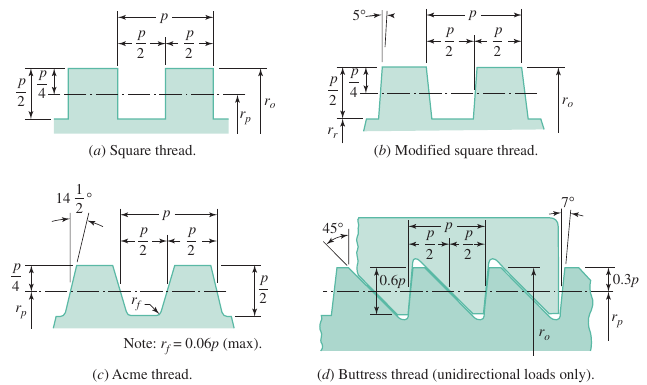

In [ ]:
r_f = 0.06*p
print(f'radio de curvatura = {r_f} in')
print(f'r_f/d_r = {r_f/d_r}')
print(f'r_o/r_r = {d/d_r}')

radio de curvatura = 0.03 in
r_f/d_r = 0.012
r_o/r_r = 1.2


In [ ]:
print('concentrador de esfueerzos por Flexión')
K_b = 2.6
print(f'K_b = {K_b}')

concentrador de esfueerzos por Flexión
K_b = 2.6


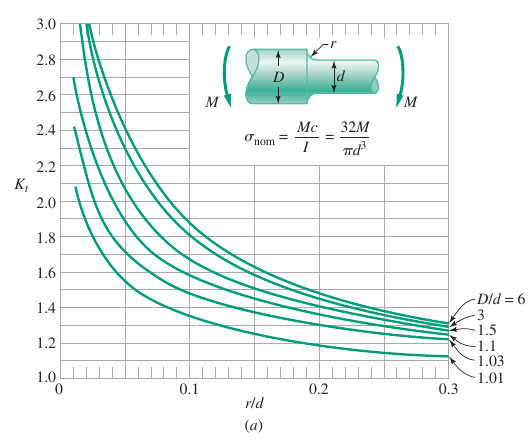

In [ ]:
print('concentrador de esfueerzos por carga axial')
K_d = 2.9
print(f'K_d = {K_d}')

concentrador de esfueerzos por carga axial
K_d = 2.9


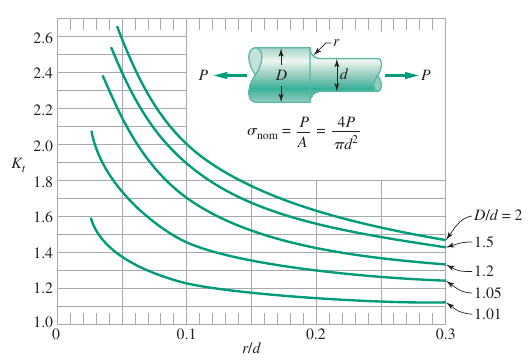

In [ ]:
print('concentrador de esfueerzos por carga Torsión')
K_t = 2.3
print(f'K_t = {K_t}')

concentrador de esfueerzos por carga Torsión
K_t = 2.3


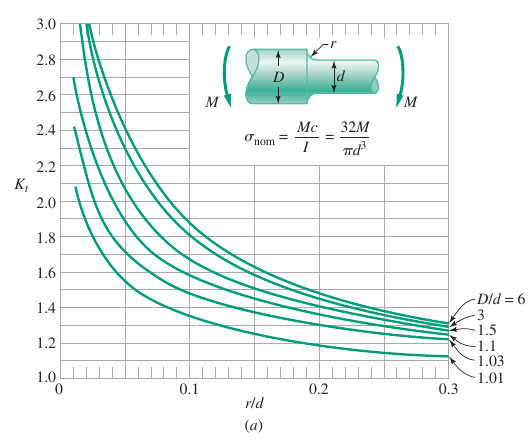

De la Figura se puede ver que para el acero 1020 (Su = 61 ksi) el índice de sensibilidad a la entalla para $r_f$ = 0,03 pulgadas está en el rango de **0,60 a 0,65** para tensión y de **0,65 a 0,70** para torsión.

In [ ]:
print('Sensibilidad a la entalla ')
q_b = 0.65
q_d = 0.65
print(f'q_b = q_d = {q_b}')
q_t = 0.7
print(f'q_s {q_t}')

Sensibilidad a la entalla 
q_b = q_d = 0.65
q_s 0.7


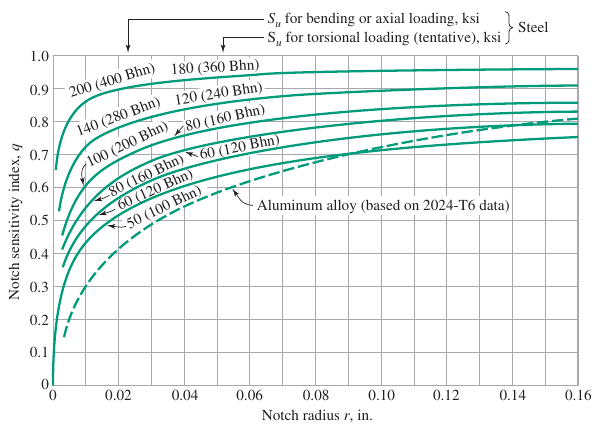

In [ ]:
K_fb = q_b* (K_b - 1) + 1
K_fd = q_d* (K_d - 1) + 1
K_ft = q_t* (K_t - 1) + 1
print('Los concentradores de esfuerzos por fatiga estan dados por:')
print(f'   Carga Flexión (K_fb) = {K_fb:.4f}')
print(f'   Carga Axial   (K_fd) = {K_fd:.4f}')
print(f'   Carga Torsión (K_ft) = {K_ft:.4f}')

Los concentradores de esfuerzos por fatiga estan dados por:
   Carga Flexión (K_fb) = 2.0400
   Carga Axial   (K_fd) = 2.2350
   Carga Torsión (K_ft) = 1.9100


In [ ]:
# Punto C

# Esfuerzo Medio
sig_x = (sigma_x+0)/2  # en Ksi, por ejemplo
sig_y = 0
sig_z = (sigma_z+0)/2

ta_xy   = 0
ta_yz   = (tau_s+0)/2
ta_zx   = 0

sig_C_m = von_mises_3d(sig_x, sig_y, sig_z,
                     ta_xy, ta_yz, ta_zx)
print("Esfuerzo medio:", sig_C_m, "psi")

# Esfuerzo Alternante
sig_x = K_fb*(sigma_x+0)/2  # en Ksi, por ejemplo
sig_y = 0
sig_z = K_fd*(sigma_z+0)/2

ta_xy   = 0
ta_yz   = K_ft*(tau_s+0)/2
ta_zx   = 0

sig_C_a = von_mises_3d(sig_x, sig_y, sig_z,
                     ta_xy, ta_yz, ta_zx)
print("Esfuerzo Alternante:", sig_C_a, "psi")

Esfuerzo medio: 1354.337374709896 psi
Esfuerzo Alternante: 2783.095048828559 psi


### Evaluación del esfuerzo máximo

In [ ]:
### Esfuerzo Máximo en los Puntos B y C

sig_max_B = sig_B_m + sig_B_a
print("Esfuerzo Máximo en el puunto B:", sig_max_B, "psi")

sig_max_C = sig_C_m + sig_C_a
print("Esfuerzo Máximo en el puunto C:", sig_max_C, "psi")

print(f'El esfuerzo maximo en B  {sig_max_B:.4f} es mayor que Sy = {Sy}?')
print(f'El esfuerzo maximo en C  {sig_max_C:.4f} es mayor que Sy = {Sy}?')

Esfuerzo Máximo en el puunto B: 4214.008767030986 psi
Esfuerzo Máximo en el puunto C: 4137.432423538455 psi
El esfuerzo maximo en B  4214.0088 es mayor que Sy = 51000?
El esfuerzo maximo en C  4137.4324 es mayor que Sy = 51000?


In [ ]:
def Goodman_modified(sigma_a, sigma_m, S_u, S_yp):
    """
    Calcula el esfuerzo crítico basado en las condiciones dadas.
    sigma_a  : Esfuerzo alternante
    sigma_m  : Esfuerzo medio
    sigma_max: Esfuerzo máximo
    S_u      : Resistencia última a la tracción
    S_yp     : Límite elástico del material

    Retorna:
    sigma_CR : Esfuerzo crítico según el criterio de Goodman modificado
    """
    sigma_max = sigma_a + sigma_m
    if sigma_m >= 0:
        if sigma_max <= S_yp:
            return sigma_a / (1 - (sigma_m / S_u))
        elif sigma_max >= S_yp:
            return S_yp
    return None  # En caso de que no se cumplan las condiciones dadas


In [ ]:
# Esfuerzo Critico en el punto B
sig_CR_B =  Goodman_modified(sig_B_a, sig_B_m, Su, Sy)
print(f"Sigma_critico para el punto B: {sig_CR_B:.4f}")

# Esfuerzo Critico en el punto C
sig_CR_C =  Goodman_modified(sig_C_a, sig_C_m, Su, Sy)
print(f"Sigma_critico para el punto C: {sig_CR_C:.4f}")

# Verificación de esfuerzos en B y en
print(f'El esfuerzo critico en B  {sig_CR_B:.4f} es menor que el esfuerzo de diseño = {sigma_diseno:.4f}?')
print(f'El esfuerzo critico en C  {sig_CR_C:.4f} es menor que el esfuerzo de diseño = {sigma_diseno:.4f}?')

Sigma_critico para el punto B: 2182.3863
Sigma_critico para el punto C: 2846.2891
El esfuerzo critico en B  2182.3863 es menor que el esfuerzo de diseño = 9634.9500?
El esfuerzo critico en C  2846.2891 es menor que el esfuerzo de diseño = 9634.9500?


# Ejercicio I



El elevador de potencia mostrado en la Figura utiliza un tornillo de potencia Acme accionado por un motor para elevar la plataforma, que pesa un máximo de 3000 lb cuando está cargada. Nótese que la tuerca, que está fijada a la plataforma, no gira. El collar de empuje del tornillo de potencia presiona contra la estructura de soporte, como se muestra en la figura, y el par motor es suministrado al eje de transmisión debajo del collar de empuje, como se indica.  

La rosca es de tipo Acme de **1 1/2 pulgadas** con **4 hilos por pulgada**. El coeficiente de fricción de la rosca es **0.40**. El radio medio del collar es de **2.0 pulgadas**, y el coeficiente de fricción del collar es **0.30**.  

Si la potencia nominal de salida de la unidad motriz es de **7.5 hp**, ¿cuál es la **velocidad máxima de elevación de la plataforma** (ft/min) que se podría especificar sin exceder la potencia nominal de salida de la unidad motriz? (Indique cualquier aproximación utilizada en sus cálculos).

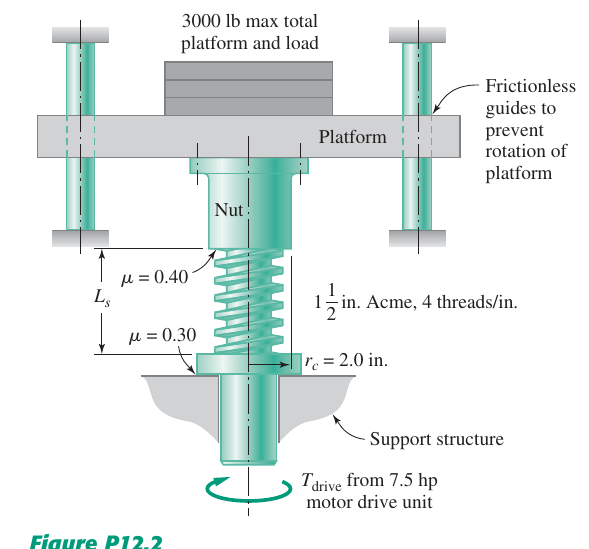

In [ ]:
alpha = 14.5*np.pi/180  # tornillo ACME diametro rosca
P = 3000                # lb  Carga
d = 1.5                 # in  diametro externo
d_r = 1.25   # in  diametro raiz
d_p = 1.375  # in diametro primitivo
p = 1/4     # in paso
L = p       # in avance = paso
mu = 0.4    # fricción rosca
d_c = 4     # in diametro del collarin
mu_c = 0.3  # fricción collarin
W = 7.5     # hp potencia minima

T_su = (P * d_p / 2) * (
    (mu * np.pi * d_p + L*np.cos(alpha)) / (
        np.pi * d_p*np.cos(alpha) - mu * L))

# Término 2: Torque debido al collar
T_c = mu_c * P * (d_c / 2)

# Torque total
T_u = T_su + T_c
print(f"Torque {T_u} lb-in")

omega = W/T_u             # hp/lb-in
omega = omega*550*12      # rad/s
omega = omega*1/(2*np.pi) # rev/s
print(f"Velocidad algular {omega} rev/s")

Vel = omega*p             # in/s
Vel = Vel*60/12           # ft/min
print(f"Velocidad linear {Vel} ft/min")

Torque 2795.308223602047 lb-in
Velocidad algular 2.8183545615935603 rev/s
Velocidad linear 3.5229432019919504 ft/min


# Ejercicio II




El ensamblaje de un elevador de tornillo de potencia debe diseñarse para levantar y bajar una **pesada tapa de hierro fundido** de una **olla de presión de 10 pies de diámetro**, utilizada en una fábrica comercial de conservas de tomate. El esquema del ensamblaje propuesto se muestra en la **Figura**.  

El peso de la tapa de hierro fundido se estima en **4000 lb**, distribuidas equitativamente entre **dos soportes**. Se observa que el **tornillo está sometido a tensión** y se ha decidido utilizar una **rosca estándar de tipo Cuadrada**.  

Los cálculos preliminares indican que la **tensión nominal** en el tornillo no debe exceder un **esfuerzo de diseño de 8000 psi**, basado en el **límite de fluencia**. Los efectos de **concentración de esfuerzos y el factor de seguridad** ya se han incluido en la especificación del esfuerzo de diseño de **8000 psi**. La fatiga puede **despreciarse** como un posible modo de falla debido al **uso poco frecuente** del ensamblaje del elevador.  

El tornillo de **acero rotativo** está soportado sobre un **cojinete de elementos rodantes** (con fricción despreciable), como se muestra en la figura, y la **tuerca no rotativa** está fabricada en **bronce poroso** (ver **Tabla Esfuerzos aplastamiento**). El **coeficiente de fricción entre el tornillo y la tuerca** se ha estimado en **0.08**.  

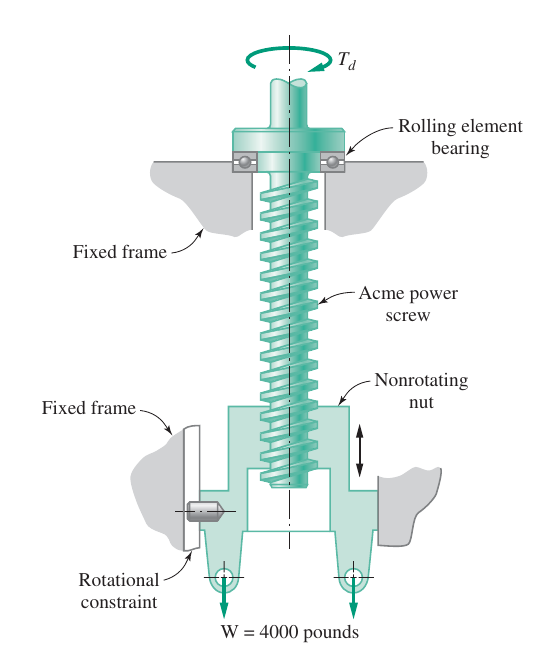

## Preguntas:  


1. Estime el **diámetro mínimo del núcleo** del tornillo, basado en el criterio de **fluencia por carga de tracción directa** como **modo de falla principal**.  

1. ¿qué **especificación de rosca Acme** sugeriría como una **primera estimación** para esta aplicación?  

1. ¿Cuál sería el **torque máximo de accionamiento** para la rosca Acme especificada ?  

1. ¿Qué **esfuerzo cortante torsional** se induciría en la **sección transversal del núcleo** del tornillo de potencia, debido al **torque de accionamiento**?  

1. Identifique los **puntos críticos** que deberían investigarse en el tornillo de potencia de rosca Acme.  

1. Revise la **zona de contacto** entre las **roscas del tornillo y de la tuerca**, y **redimensione el tornillo** si es necesario. Suponga que la **carga total es soportada por tres roscas**. Si se requiere un **redimensionamiento**, **recalcule el torque de accionamiento** para el **nuevo tamaño del tornillo**.  

1. ¿Cuánta **potencia de entrada** (hp) sería necesaria para accionar el tornillo del tamaño determinado en **(6)**, si se desea **levantar la tapa 18 pulgadas en no más de 15 segundos**?

# Refeerencias

1. **Shigley, J. E., Nisbett, J. K., & Budynas, R. G.** (2021). *Diseño en ingeniería mecánica de Shigley* (11ª ed.). McGraw-Hill. ISBN: 1456267566.

2. **Norton, R. L.** (2020). *Machine design: an integrated approach* (6ª ed.). Prentice Hall. ISBN: 9780135184233.  

3. **Mott, R. L., Vavrek, E. M., & Wang, J.** (2018). *Machine Elements in Mechanical Design* (6ª ed.). Pearson. ISBN: 978-0134441184.  

4. **Deutschman, A. D., Michels, W. J., & Wilson, C. E.** (1987). *Diseño de Máquinas: Teoría y Práctica* (2ª impresión). Compañía Editorial Continental. ISBN: 968-26-0600-4. Traducción al español de José Armando Garza Cárdenas.

5. **Collins, J. A., Busby, H. R., & Staab, G. H.** (2009). *Mechanical Design of Machine Elements and Machines: A Failure Prevention Perspective* (2ª ed.). Wiley. ISBN: 0470413034.

6. **Juvinall, R. C., & Marshek, K. M.** (2020). *Fundamentals of Machine Component Design* (7ª ed.). Wiley. ISBN: 9781119493761.

7. **Hall, A. S., Holowenko, A. R., & Laughlin, H. G.** (1971). *Diseño de máquinas*. McGraw-Hill (Serie de Compendios Schaum). ISBN: 9684510772.